# 04 · Quasi-Monte Carlo

Random points clump and leave gaps; for integration we would rather have points that fill the cube evenly.
Low-discrepancy sequences - van der Corput, Halton, Sobol, lattice rules - do exactly that, and the
Koksma-Hlawka inequality turns evenness (discrepancy) into an error bound of order (log n)ᵈ/n. Randomising
them restores what QMC loses - an error estimate - and keeps most of the gain.

**What you will learn**
- construct van der Corput, Halton and lattice point sets
- measure discrepancy and relate it to integration error
- compare QMC and MC convergence on smooth integrands
- obtain error estimates by randomised QMC

**Before you start:** notebooks 02-03  ·  **Time:** about 60 min

In [1]:
try:                      # on Google Colab (or anywhere engstoch is missing): install it from GitHub
    import engstoch
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "git+https://github.com/ktwyw/engstoch"], check=True)
import math
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import qmc as sqmc
from engstoch import qmc, montecarlo as mc
plt.rcParams.update({"figure.figsize": (7, 4), "figure.dpi": 90, "axes.grid": True, "grid.alpha": 0.3,
                     "axes.spines.top": False, "axes.spines.right": False})

import inspect
from IPython.display import Code

def show_source(obj):
    """Display the source code of a library function or class."""
    return Code(inspect.getsource(obj), language="python")

R = np.random.default_rng      # R(seed): a fresh, reproducible generator

## Low-discrepancy points

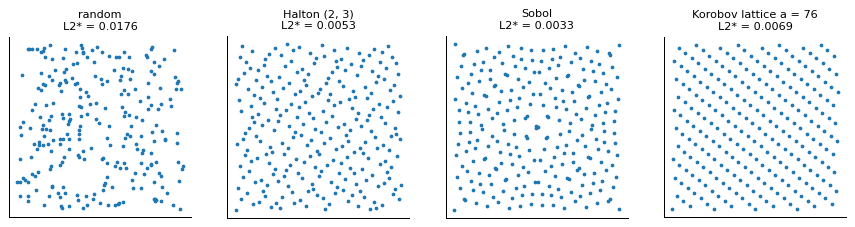

van der Corput base 2: [0.0, 0.5, 0.25, 0.75, 0.125, 0.625, 0.375, 0.875]
Sobol and Halton agree with SciPy: True True


In [2]:
fig, axes = plt.subplots(1, 4, figsize=(12, 3.2))
sets = {"random": R(1).random((256, 2)), "Halton (2, 3)": qmc.halton(256, 2), "Sobol": qmc.sobol(256, 2), "Korobov lattice a = 76": qmc.korobov(256, 2, 76)}
for ax, (name, x) in zip(axes, sets.items()):
    ax.scatter(*x.T, s=4); ax.set_title(f"{name}\nL2* = {qmc.l2_star_discrepancy(x):.4f}", fontsize=9); ax.set_aspect("equal"); ax.set_xticks([]); ax.set_yticks([])
plt.show()
print("van der Corput base 2:", qmc.van_der_corput(8).tolist())
print("Sobol and Halton agree with SciPy:", np.array_equal(qmc.sobol(512, 6), sqmc.Sobol(6, scramble=False).random(512)), np.allclose(qmc.halton(300, 4), sqmc.Halton(4, scramble=False).random(300)))

The van der Corput sequence mirrors the digits of 0, 1, 2, … about the radix point, so each new point falls
into the largest remaining gap. Halton uses a different prime base per coordinate; Sobol uses base 2 with
"direction numbers" chosen so that the first 2ᵐ points put exactly one point in every elementary box of a
fixed shape (a (t, m, s)-net); a rank-1 lattice is {i z/n mod 1}. The L2-star discrepancy, computed exactly by
Warnock's formula, quantifies the evenness.

## Convergence: n⁻¹ instead of n⁻¹ᐟ²

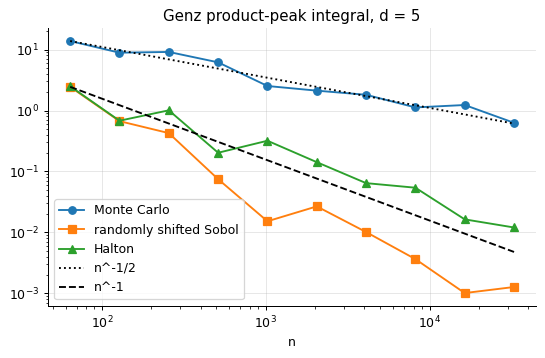

slopes: MC -0.49, Sobol -1.25, Halton -0.81


In [3]:
d = 5
f = lambda x: qmc.genz_product_peak(x)
exact = qmc.genz_product_peak_integral(d)
ms = np.arange(6, 16)
err_mc = [np.mean([abs(np.mean(f(R(100 * m + k).random((2**m, d)))) - exact) for k in range(10)]) for m in ms]
err_sob = [np.mean([abs(np.mean(f(np.mod(qmc.sobol(2**m, d) + R(m * 10 + k).random(d), 1))) - exact) for k in range(10)]) for m in ms]
err_hal = [abs(np.mean(f(qmc.halton(2**m, d, start=1))) - exact) for m in ms]
n = 2.0**ms
plt.loglog(n, err_mc, "o-", label="Monte Carlo"); plt.loglog(n, err_sob, "s-", label="randomly shifted Sobol"); plt.loglog(n, err_hal, "^-", label="Halton")
plt.loglog(n, err_mc[0] * (n / n[0]) ** -0.5, "k:", label="n^-1/2"); plt.loglog(n, err_sob[0] * (n / n[0]) ** -1, "k--", label="n^-1"); plt.legend(); plt.xlabel("n"); plt.title(f"Genz product-peak integral, d = {d}"); plt.show()
print(f"slopes: MC {np.polyfit(np.log(n), np.log(err_mc), 1)[0]:.2f}, Sobol {np.polyfit(np.log(n), np.log(err_sob), 1)[0]:.2f}, Halton {np.polyfit(np.log(n), np.log(err_hal), 1)[0]:.2f}")

For a smooth integrand in five dimensions QMC's error falls nearly like 1/n - at 32 000 points two orders of
magnitude below Monte Carlo's. The advantage shrinks for discontinuous integrands and in high nominal
dimension unless the function has low "effective dimension" (most variance in a few coordinates or in
low-order interactions) - which is often true in practice and is why QMC works in finance with hundreds of
dimensions.

## Randomised QMC: an error estimate again

In [4]:
rows = []
for m in (8, 10, 12):
    pts = qmc.sobol(2**m, d)
    r = qmc.randomised_qmc(f, pts, 16, R(m))
    plain = mc.mean_ci(f(R(m + 50).random((16 * 2**m, d))))
    rows.append((16 * 2**m, r["estimate"] - exact, r["std_error"], plain["std_error"], (plain["std_error"] / r["std_error"]) ** 2))
print(pd.DataFrame(rows, columns=["evaluations", "RQMC error", "RQMC std error (16 shifts)", "MC std error, same budget", "variance reduction"]).to_string(index=False, float_format="%.3g"))

 evaluations  RQMC error  RQMC std error (16 shifts)  MC std error, same budget  variance reduction
        4096      -0.177                       0.114                       2.25                 391
       16384     0.00435                     0.00638                       1.14            3.17e+04
       65536      -0.002                     0.00352                       0.57            2.62e+04


A deterministic point set gives no error estimate. Shifting the whole set by a uniform random vector modulo 1
(a Cranley-Patterson rotation) makes each average unbiased; a handful of independent shifts gives a t
interval. Some convergence order is traded for the estimate, but the variance reduction over plain Monte
Carlo still runs into the hundreds or thousands.

## Pitfalls: Halton in high bases, lattice generators

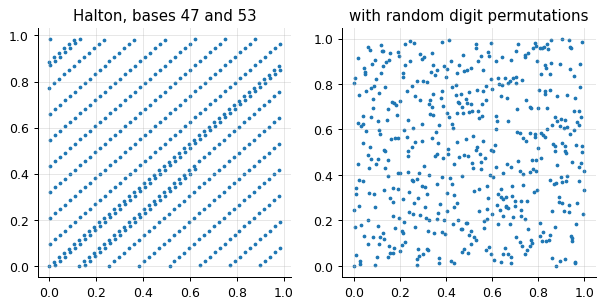

Korobov n = 1021, d = 4, a =   2: L2* discrepancy 0.05810
Korobov n = 1021, d = 4, a =  76: L2* discrepancy 0.00221


Korobov n = 1021, d = 4, a = 270: L2* discrepancy 0.00490


In [5]:
x = qmc.halton(500, 16)
xs = qmc.halton(500, 16, rng=R(3), scramble="permute")
fig, axes = plt.subplots(1, 2, figsize=(8, 3.6))
axes[0].scatter(x[:, 14], x[:, 15], s=4); axes[0].set_title("Halton, bases 47 and 53")
axes[1].scatter(xs[:, 14], xs[:, 15], s=4); axes[1].set_title("with random digit permutations"); plt.show()
best = qmc.search_korobov(1021, 4)
for a in (2, 76, best["a"]):
    print(f"Korobov n = 1021, d = 4, a = {a:>3}: L2* discrepancy {qmc.l2_star_discrepancy(qmc.korobov(1021, 4, a)):.5f}")

In high prime bases the first few hundred Halton points march along diagonal lines (the two radical inverses
grow in step); random digit permutations break the correlation. A lattice rule is only as good as its
generating vector: a = 2 is disastrous. Practical rules come from a computer search over a for the smallest
worst-case error in a chosen function space - here a smoothness-2 Korobov space, whose winner is not the one with
the smallest L2-star discrepancy: different criteria rank generators differently, but all good ones beat a bad
one by an order of magnitude.

## Inside the algorithm: Warnock's formula

In [6]:
x = qmc.sobol(64, 2)
n, d = x.shape
t1 = 3.0**-d; t2 = 2.0 ** (1 - d) / n * np.sum(np.prod(1 - x**2, axis=1))
t3 = np.sum(np.prod(1 - np.maximum(x[:, None, :], x[None, :, :]), axis=2)) / n**2
print(f"L2-star discrepancy by hand {np.sqrt(t1 - t2 + t3):.6f}; library {qmc.l2_star_discrepancy(x):.6f}")

L2-star discrepancy by hand 0.012870; library 0.012870


## Exercises
1. Price a European call by QMC: map Sobol points through the normal quantile and compare the error with MC for n = 2^8..2^16. Then do the same for a digital option (payoff 1 if S_T > K). Is the gain smaller, as one might expect for a discontinuous payoff?
2. For the integrand prod_j (1 + (x_j - 1/2)/j^2) in d = 20, compare MC and randomly shifted Sobol (use d <= 10 Sobol plus 10 Halton coordinates if you prefer). Explain the result with the idea of effective dimension.
3. **Implement it yourself:** write the radical inverse function in any base with integer arithmetic and reproduce `qmc.halton(100, 5)` exactly.